Model loaded from /Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/models/NN.pth
MAE (Testing): 0.04444124549627304
RMSE (Testing): 0.06606082624360507
R-squared (Testing): 0.9961527


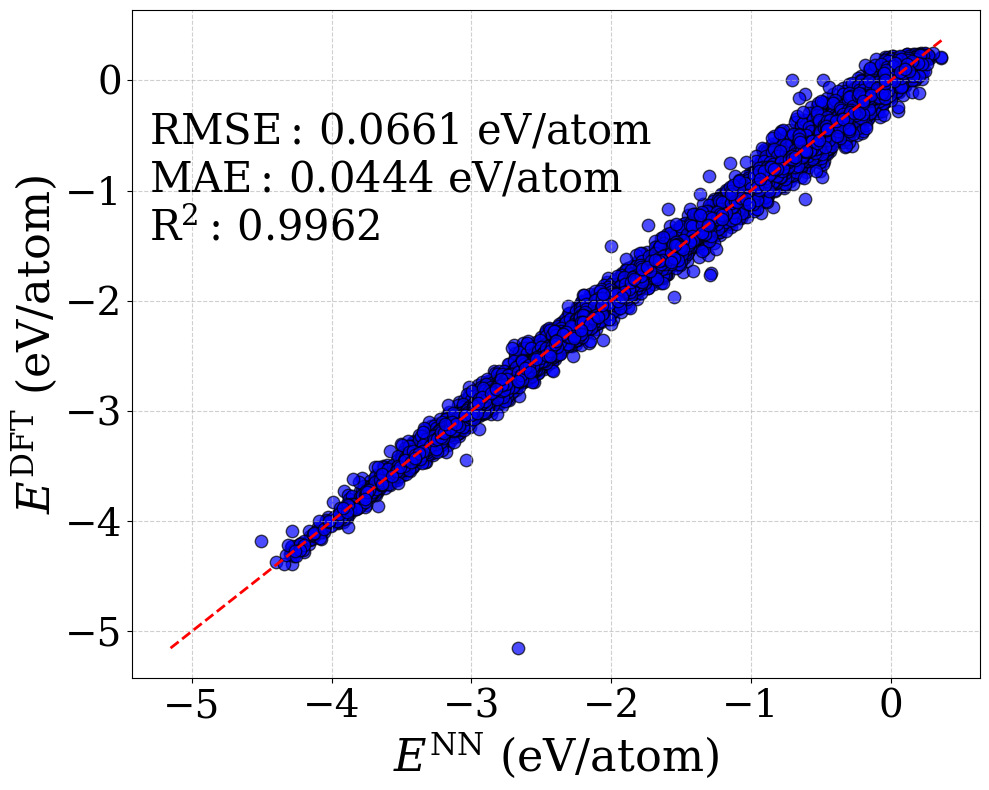

In [8]:
import numpy as np
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import os

# -------------------------------
# SETUP & DATA LOADING (as before)
# -------------------------------

# Create the directory for snapshots if needed (for saving the plot)
snapshot_dir = 'plots'
os.makedirs(snapshot_dir, exist_ok=True)

# Load the scaler and any JSON data if needed (example shown for the scaler)
# Assume 'formation_energies_valid.json' and other files were used in preprocessing.
with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/scalers_and_data/formation_energies_valid_0_25eV.json', 'r') as file:
    formation_energies_valid = json.load(file)

# Load your features tensor
features_tensor = torch.load('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/scalers_and_data/features_tensor_0_25eV.pt')
features_tensor_combined = torch.stack(features_tensor)

# Normalize target values with the same scaler used during training
scaler_y = MinMaxScaler(feature_range=(0, 1))
formation_energies_tensor = torch.tensor(
    scaler_y.fit_transform(np.array(formation_energies_valid).reshape(-1, 1)),
    dtype=torch.float32
).squeeze()

# Split data into training and testing sets (we only need test later)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_tensor_combined,
                                                    formation_energies_tensor,
                                                    test_size=0.2, random_state=23)

# Set up device and transfer test data to the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test = X_test.to(device)
y_test = y_test.to(device)
y_test = y_test.view(-1, 1)  # Reshape if necessary

# -------------------------------
# MODEL SETUP
# -------------------------------

# Define your model class (DeepSet here)
class DeepSet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepSet, self).__init__()
        self.rho = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        output = self.rho(x)
        return output

# Set parameters (use the same as used during training)
input_dim = features_tensor[0].shape[-1]  # Get the feature dimension
hidden_dim = 512
output_dim = 1

# Initialize the model and transfer it to the device
model = DeepSet(input_dim, hidden_dim, output_dim).to(device)

# -------------------------------
# LOAD SAVED MODEL
# -------------------------------
model_path = '/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/models/NN.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Model loaded from", model_path)
else:
    print("Model file not found!")
    
# IMPORTANT: Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    predicted_values_test = model(X_test)

# -------------------------------
# POST-PROCESSING & METRICS
# -------------------------------

# Inverse transform predictions to the original formation energy scale
y_test_inverse = scaler_y.inverse_transform(y_test.cpu().numpy().reshape(-1, 1))
predicted_values_test_inverse = scaler_y.inverse_transform(predicted_values_test.cpu().numpy().reshape(-1, 1))

# Calculate error metrics
mae_test = mean_absolute_error(y_test_inverse, predicted_values_test_inverse)
rmse_test = np.sqrt(mean_squared_error(y_test_inverse, predicted_values_test_inverse))
r_squared_test = 1 - np.sum((y_test_inverse - predicted_values_test_inverse)**2) / np.sum((y_test_inverse - np.mean(y_test_inverse))**2)

print("MAE (Testing):", mae_test)
print("RMSE (Testing):", rmse_test)
print("R-squared (Testing):", r_squared_test)


# -------------------------------
import matplotlib as mpl

# Use the default style for a clean white background and black labels
plt.style.use('default')

# Update font settings AFTER applying the style.
mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the test data as a scatter plot with the specified formatting
scatter = ax.scatter(predicted_values_test_inverse, y_test_inverse, 
                     color='blue', s=80, edgecolor='black', alpha=0.7, 
                     label='Test Data')

# Plot the ideal (45°) line: perfect agreement between predicted and actual values
min_val = min(y_test_inverse.min(), predicted_values_test_inverse.min())
max_val = max(y_test_inverse.max(), predicted_values_test_inverse.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='red', linestyle='--', linewidth=2, label='Ideal Fit')

# Add error metrics (RMSE, MAE, R²) as a text box on the plot using LaTeX formatting
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textstr = (
    r'$\mathrm{RMSE:}\, %.4f\ \text{eV/atom}$' '\n'
    r'$\mathrm{MAE:}\, %.4f\ \text{eV/atom}$' '\n'
    r'$\mathrm{R}^{2}:\, %.4f$' % (rmse_test, mae_test, r_squared_test)
)
ax.text(0.02, 0.85, textstr, transform=ax.transAxes, fontsize=30,
        verticalalignment='top')

# Set the axis labels using LaTeX formatting for mathematical expressions; ensure labels are black
ax.set_ylabel(r'$E^{\mathrm{DFT}}\ (\text{eV/atom})$', fontsize=32, color='black')
ax.set_xlabel(r'$E^{\mathrm{NN}}\ (\text{eV/atom})$', fontsize=32, color='black')

# Adjust tick parameters (labels set to black)
ax.tick_params(axis='both', which='major', labelsize=28, colors='black')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid for better readability

# Save the plot at high resolution for publication quality
plot_filename = os.path.join(snapshot_dir, 'NN_testing.png')
plt.savefig(plot_filename, dpi=300)
plt.show()

Using device: cpu
Features shape: torch.Size([51068, 118])
Targets shape: torch.Size([51068, 1])
Target range (raw file): -5.153567790985107 to 0.024900389835238457
Heuristic: targets are RAW eV (not scaled)
Loaded max-affine: K=7, d=118
MAE (Testing): 0.07606711983680725
RMSE (Testing): 0.10843408702899063
R-squared (Testing): 0.9892857


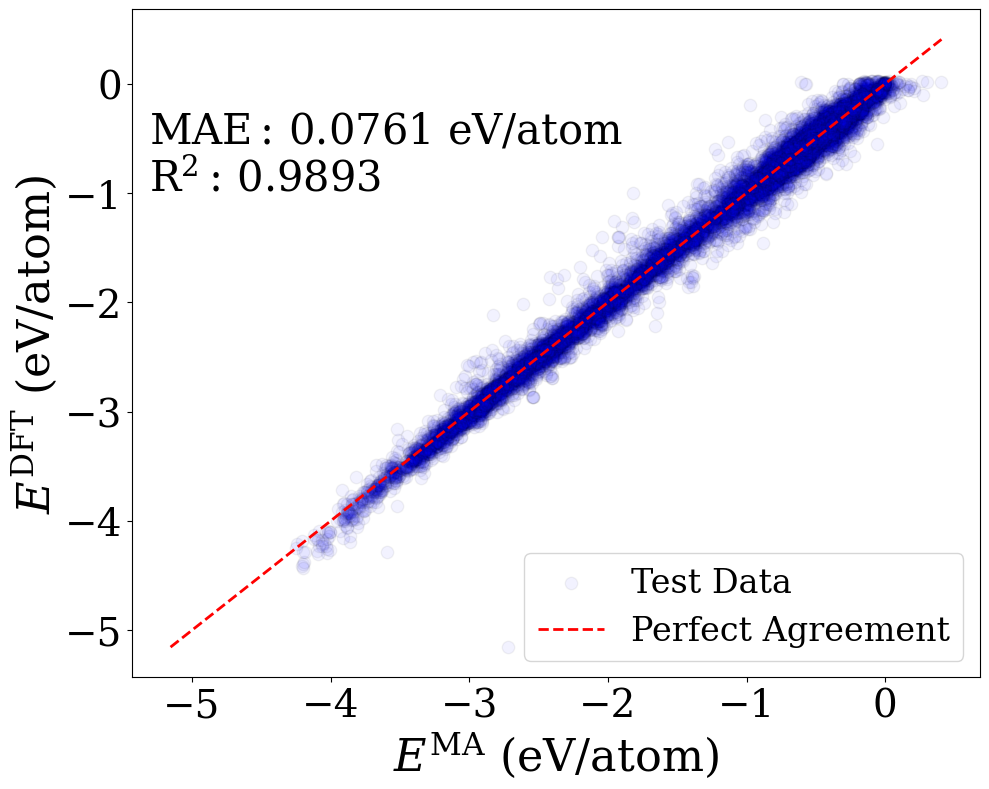

Saved plot to: plots/MA-7_testing.png


In [13]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# PATHS
# ============================================================
BASE = "/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final"

SCALER_Y_JSON      = os.path.join(BASE, "scalers_and_data", "scaler_y_0_025eV.json")
FE_JSON            = os.path.join(BASE, "scalers_and_data", "formation_energies_valid_0_025eV.json")
FEATURES_TENSOR_PT = os.path.join(BASE, "scalers_and_data", "features_tensor_0_025eV.pt")

OH_ELEMENTS_JSON   = os.path.join(BASE, "other_data_and_plots", "helper_objects", "OH_elements.json")
P_DICT_OH_JSON     = os.path.join(BASE, "other_data_and_plots", "helper_objects", "p_dict_oh.json")

MAX_AFFINE_PT      = os.path.join(BASE, "other_data_and_plots", "models", "MA-7.pt")

PLOT_DIR           = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)


# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# LOAD MinMaxScaler FROM JSON (exactly as you were doing)
# ============================================================
with open(SCALER_Y_JSON, "r") as f:
    scaler_params = json.load(f)

scaler_y = MinMaxScaler(feature_range=tuple(scaler_params["feature_range"]))
scaler_y.min_        = np.array(scaler_params["min_"])
scaler_y.scale_      = np.array(scaler_params["scale_"])
scaler_y.data_min_   = np.array(scaler_params["data_min_"])
scaler_y.data_max_   = np.array(scaler_params["data_max_"])
scaler_y.data_range_ = np.array(scaler_params["data_range_"])


# ============================================================
# INVERSE SCALER (torch module)
#   For sklearn MinMaxScaler:
#     X_scaled = X * scale_ + min_
#     X = (X_scaled - min_) / scale_
#
# ============================================================
class InverseScaler(nn.Module):
    def __init__(self, min_, scale_):
        super().__init__()
        self.register_buffer("min_t",   torch.tensor(min_,   dtype=torch.float32))
        self.register_buffer("scale_t", torch.tensor(scale_, dtype=torch.float32))

    def forward(self, x_scaled):
        # x_scaled: [..., 1] or [...], broadcast works
        return (x_scaled - self.min_t) / self.scale_t


# ============================================================
# MAX-AFFINE PREDICTOR (HARD MAX)
# y(x) = max_j (w_j^T x + b_j)
# ============================================================
class MaxAffine(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        # W: [K, d], b: [K]
        self.W = nn.Parameter(W, requires_grad=False)
        self.b = nn.Parameter(b, requires_grad=False)

    def forward(self, x):
        # x: [N, d]
        z = x @ self.W.t() + self.b[None, :]     # [N, K]  <-- FIXED BROADCASTING
        y = z.max(dim=1).values.view(-1, 1)      # [N, 1]
        return y


# ============================================================
# WRAPPER: MODEL OUTPUT IN eV/atom (inverse scaling)
# ============================================================
class MaxAffineWithInverseScaling(nn.Module):
    def __init__(self, max_affine_model, scaler_y: MinMaxScaler):
        super().__init__()
        self.max_affine_model = max_affine_model
        self.inverse_scaler = InverseScaler(scaler_y.min_, scaler_y.scale_)

    def forward(self, x):
        y_scaled = self.max_affine_model(x)      # scaled target space
        y_eV     = self.inverse_scaler(y_scaled) # back to eV
        return y_eV


# ============================================================
# LOAD FEATURES
# ============================================================
features_tensor = torch.load(FEATURES_TENSOR_PT)
features_tensor_combined = torch.stack(features_tensor)  # [N, d]
N, d = features_tensor_combined.shape
print("Features shape:", features_tensor_combined.shape)


# ============================================================
# LOAD FORMATION ENERGIES
#   IMPORTANT: we will detect if these are already in eV or scaled.
# ============================================================
with open(FE_JSON, "r") as f:
    fe_list = json.load(f)

formation_energies_tensor = torch.tensor(fe_list, dtype=torch.float32).view(-1, 1)  # [N,1]
print("Targets shape:", formation_energies_tensor.shape)


# ============================================================
# DETECT WHETHER TARGETS ARE ALREADY SCALED OR IN eV
#
# If targets look like they're in [0,1], treat as scaled and inverse-transform.
# Otherwise treat as eV and DO NOT inverse-transform y_test.
# ============================================================
y_np = formation_energies_tensor.numpy()
is_probably_scaled = (y_np.min() >= -1e-6) and (y_np.max() <= 1.0 + 1e-6)

print("Target range (raw file):", float(y_np.min()), "to", float(y_np.max()))
print("Heuristic: targets are", ("SCALED [0,1]" if is_probably_scaled else "RAW eV (not scaled)"))


# ============================================================
# LOAD p_dict_oh (only to verify d matches input_dim as you were doing)
# ============================================================
with open(P_DICT_OH_JSON, "r") as f:
    p_dict_oh = json.load(f)

input_dim = len(p_dict_oh["H"])
assert input_dim == d, f"Feature dim mismatch: features have d={d}, but p_dict_oh['H'] has {input_dim}"


# ============================================================
# LOAD MAX-AFFINE CHECKPOINT
# Expect: torch.save({'W': [K,d], 'b': [K]}, path)
# ============================================================
ckpt = torch.load(MAX_AFFINE_PT, map_location=device)
W = ckpt["W"].float().to(device)
b = ckpt["b"].float().to(device)

assert W.dim() == 2 and b.dim() == 1, "Checkpoint must contain W[K,d] and b[K]"
assert W.shape[1] == input_dim, f"W has d={W.shape[1]} but input_dim={input_dim}"

K = W.shape[0]
print(f"Loaded max-affine: K={K}, d={W.shape[1]}")


# ============================================================
# BUILD MODEL (outputs eV)
# ============================================================
ma_model = MaxAffine(W, b).to(device)
combined_model = MaxAffineWithInverseScaling(ma_model, scaler_y).to(device)
combined_model.eval()


# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    features_tensor_combined,
    formation_energies_tensor,
    test_size=0.2,
    random_state=1278
)

X_test = X_test.to(device)
y_test = y_test.to(device)


# ============================================================
# PREDICT (eV)
# ============================================================
with torch.no_grad():
    y_pred_eV = combined_model(X_test).detach().cpu().numpy()  # [Ntest,1]


# ============================================================
# GET y_true IN eV
# ============================================================
y_test_np = y_test.detach().cpu().numpy().reshape(-1, 1)

if is_probably_scaled:
    # If file was scaled, invert to eV for plotting/metrics
    y_true_eV = scaler_y.inverse_transform(y_test_np)
else:
    # If file was already eV, use directly
    y_true_eV = y_test_np


# ============================================================
# METRICS
# ============================================================
mae_test = mean_absolute_error(y_true_eV, y_pred_eV)
rmse_test = np.sqrt(mean_squared_error(y_true_eV, y_pred_eV))
r_squared_test = 1 - np.sum((y_true_eV - y_pred_eV) ** 2) / np.sum((y_true_eV - np.mean(y_true_eV)) ** 2)

print("MAE (Testing):", mae_test)
print("RMSE (Testing):", rmse_test)
print("R-squared (Testing):", r_squared_test)


# ============================================================
# PLOT (publication-style)
# ============================================================
plt.style.use("default")
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "dejavuserif"

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    y_pred_eV, y_true_eV,
    color="blue", s=80, edgecolor="black", alpha=0.05,
    label="Test Data"
)

min_val = float(min(y_true_eV.min(), y_pred_eV.min()))
max_val = float(max(y_true_eV.max(), y_pred_eV.max()))
ax.plot([min_val, max_val], [min_val, max_val],
        color="red", linestyle="--", linewidth=2, label="Perfect Agreement")

# textstr = (
#     r"$\mathrm{RMSE:}\, %.4f\ \text{eV/atom}$" "\n"
#     r"$\mathrm{MAE:}\, %.4f\ \text{eV/atom}$" "\n"
#     r"$\mathrm{R}^{2}:\, %.4f$" % (rmse_test, mae_test, r_squared_test)
# )
textstr = (
    r"$\mathrm{MAE:}\, %.4f\ \text{eV/atom}$" "\n"
    r"$\mathrm{R}^{2}:\, %.4f$" % (mae_test, r_squared_test)
)
ax.text(0.02, 0.85, textstr, transform=ax.transAxes, fontsize=30, verticalalignment="top")

ax.set_xlabel(r"$E^{\mathrm{MA}}\ (\text{eV/atom})$", fontsize=32, color="black")
ax.set_ylabel(r"$E^{\mathrm{DFT}}\ (\text{eV/atom})$", fontsize=32, color="black")
ax.tick_params(axis="both", which="major", labelsize=28, colors="black")
plt.legend(fontsize=24)
plt.tight_layout()

plot_filename = os.path.join(PLOT_DIR, f"MA-{K}_testing.png")
plt.savefig(plot_filename, dpi=300)
plt.show()

print("Saved plot to:", plot_filename)


In [73]:
with torch.no_grad():
    # layers: rho = [Linear(in→hid), ReLU(), Linear(hid→out)]
    W1 = model.rho[0].weight.detach().cpu().numpy()        # [H, D]
    b1 = model.rho[0].bias.detach().cpu().numpy()          # [H]
    W2 = model.rho[2].weight.detach().cpu().numpy().squeeze(0)  # [H]
    b2 = model.rho[2].bias.detach().cpu().numpy().item()        # scalar

print("W1:\n")
print(W1)
print("\nb1:\n")
print(b1)
print("\nW2:\n")
print(W2)
print("\nb2:\n")
print(b2)

with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/training/OH_elements.json', 'r') as file:
    OH_elements = np.array(json.load(file))

# sorted_W1_0 = np.argsort(W1[0])[::-1]
# print(OH_elements[sorted_W1_0])
# sorted_W1_1 = np.argsort(W1[1])[::-1]
# print(OH_elements[sorted_W1_1])
# sorted_W1_2 = np.argsort(W1[2])[::-1]
# print(OH_elements[sorted_W1_2])
# sorted_W1_3 = np.argsort(W1[3])[::-1]
# print(OH_elements[sorted_W1_3])

W1:

[[-2.08249018e-02  1.98819160e-01  4.65894416e-02 -3.68845344e-01
  -5.08221805e-01  1.13095798e-01  6.37208998e-01  6.52804434e-01
   4.10390377e-01  6.96733519e-02  1.64870590e-01 -2.67377764e-01
  -5.71312010e-01 -7.20067799e-01 -1.05949628e+00 -1.17861211e+00
   2.58802116e-01  3.13207842e-02  1.91860795e-01 -1.15252741e-01
  -5.27801037e-01 -6.31625831e-01 -1.03906855e-01 -1.10934466e-01
   5.73554598e-02  2.08499208e-01  2.90257215e-01  2.60738224e-01
   2.13750243e-01  1.36912838e-01 -7.60942996e-02  7.91893899e-03
  -3.48770618e-01 -3.85884345e-01  2.61575520e-01  3.45412135e-01
   2.08067134e-01 -2.39718752e-03 -4.60146725e-01 -6.75852060e-01
  -1.32331997e-01  1.40989855e-01  1.69077218e-01  2.52206504e-01
   3.38610530e-01  2.67350972e-01  1.55099154e-01  1.15756348e-01
   9.16657895e-02  8.57649446e-02  9.98666957e-02 -2.49617174e-01
   2.37556964e-01  4.63753164e-01  2.16326430e-01  8.09193309e-03
  -3.93177032e-01 -5.24622560e-01 -3.84718329e-01 -4.03319240e-01
  -4.

In [2]:
import numpy as np
x1 = np.array([-4.414, 4.321, -1.181])
x2 = np.array([0.0, 12.250, -1.096])

print(np.linalg.norm(x1 - x2))

9.075222421516731
